In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats.mstats import winsorize
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier,AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder,MinMaxScaler,OneHotEncoder,StandardScaler
from sklearn.metrics import accuracy_score,precision_score,recall_score,classification_report

In [ ]:
df = pd.read_csv('/content/sample_data/BreastCancerDataset.csv')

In [ ]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df.shape

(569, 33)

In [ ]:
df['diagnosis'].value_counts()

,count
diagnosis,
B,357
M,212


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.drop(['id'],axis=1,inplace=True)

In [ ]:
df.drop(['Unnamed: 32'],axis=1,inplace=True)

In [ ]:
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


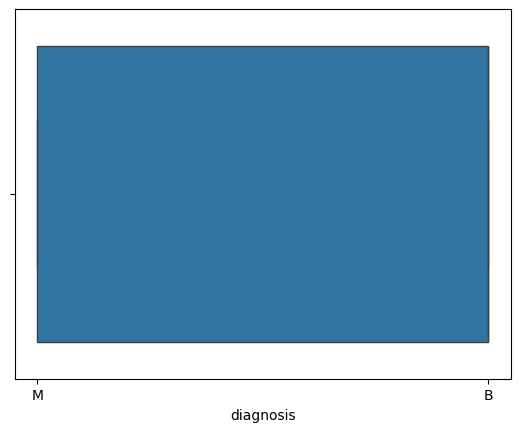

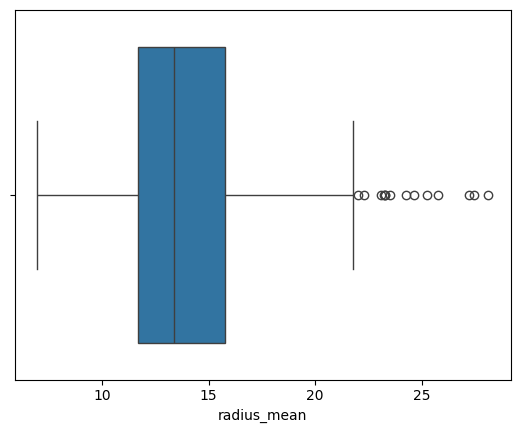

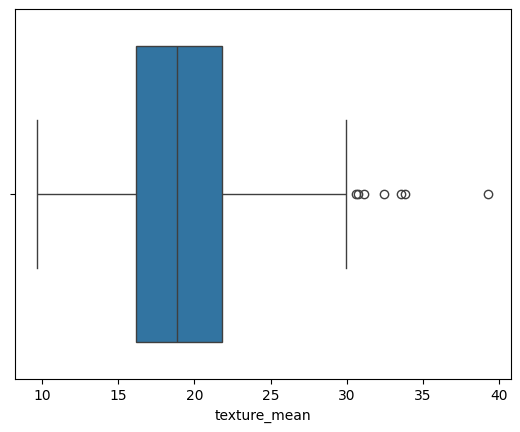

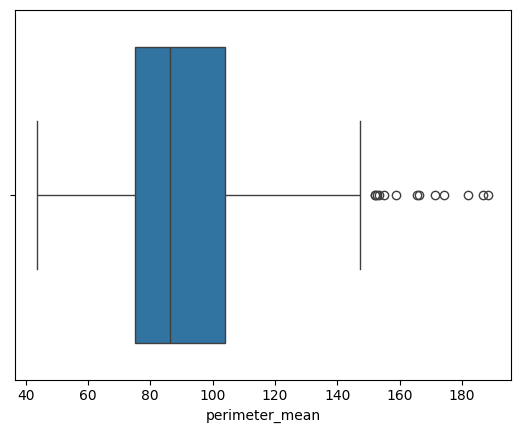

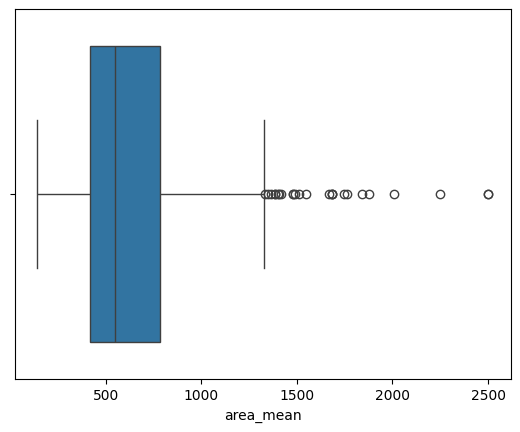

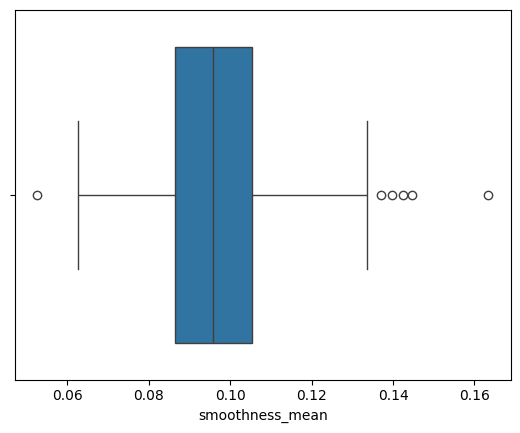

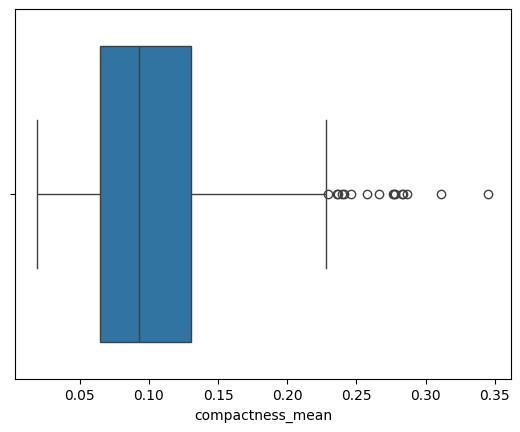

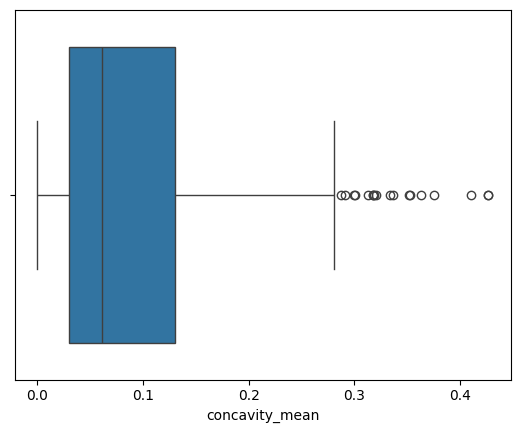

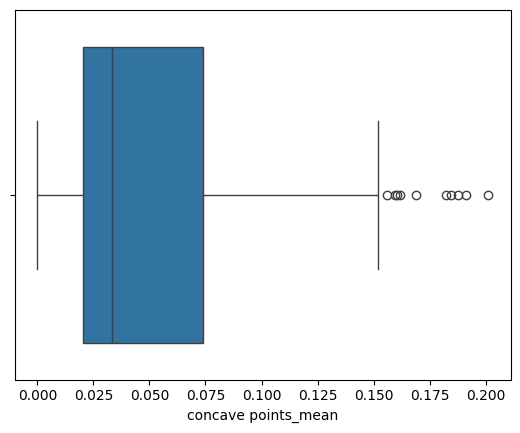

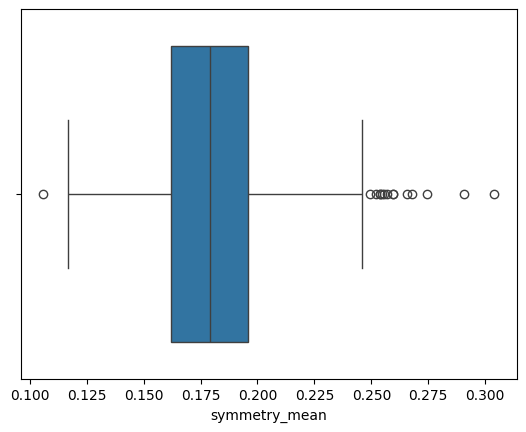

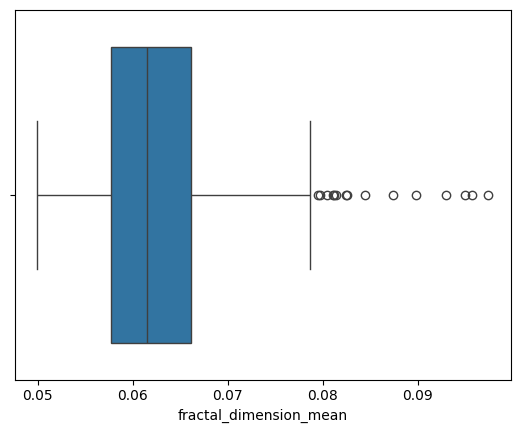

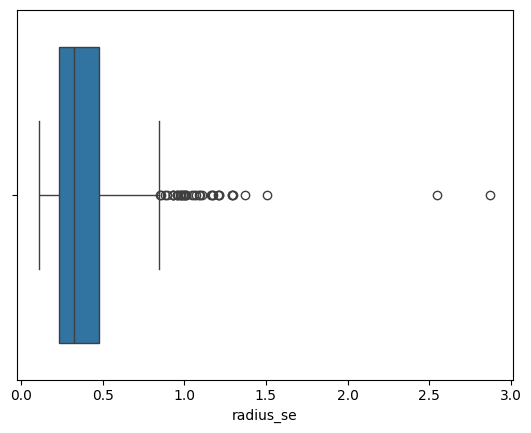

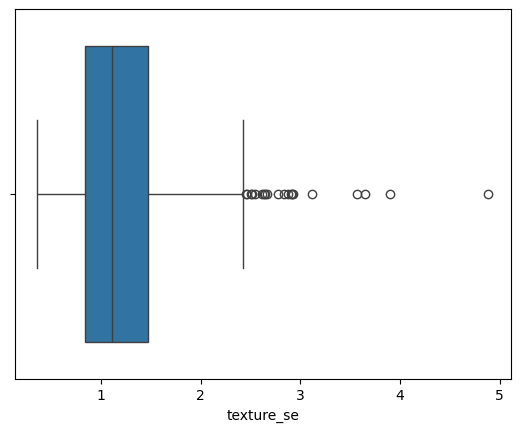

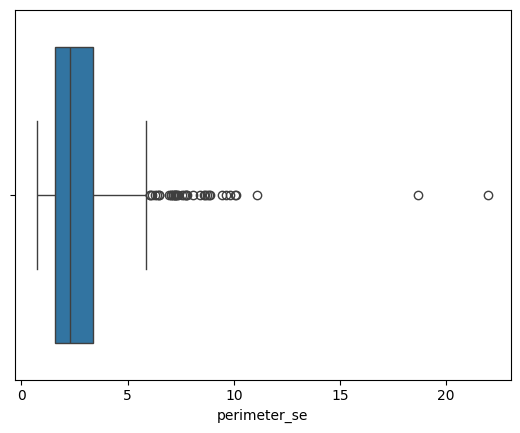

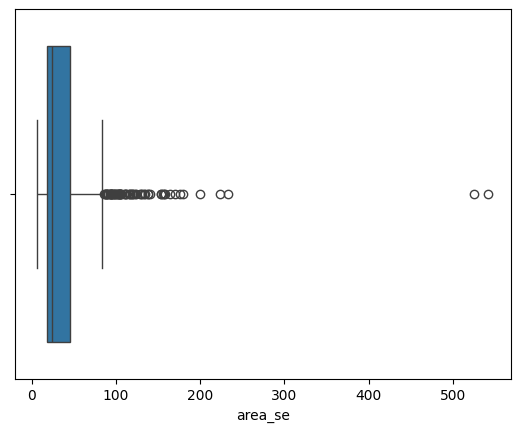

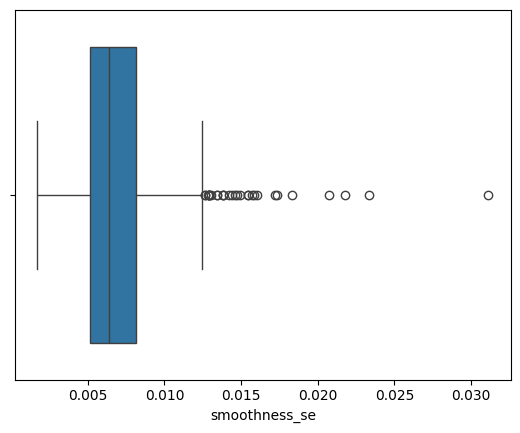

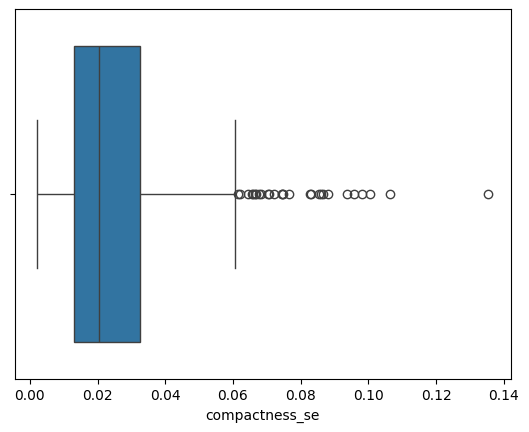

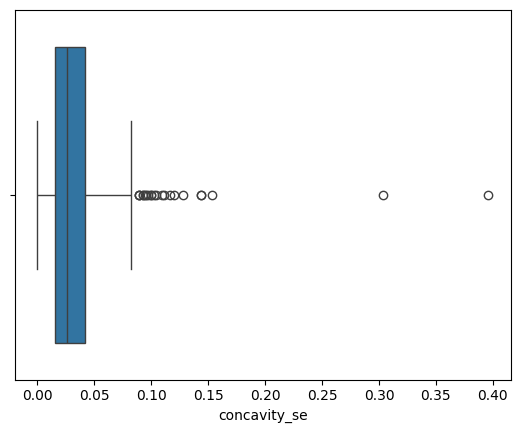

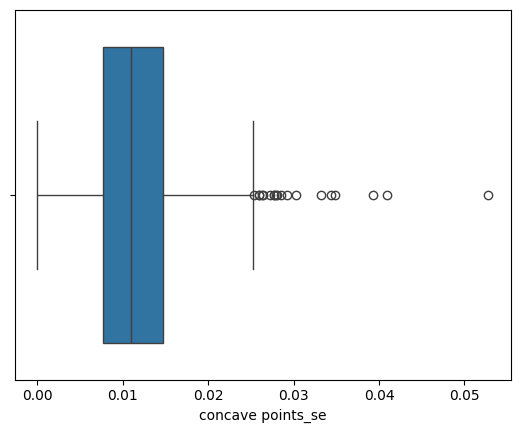

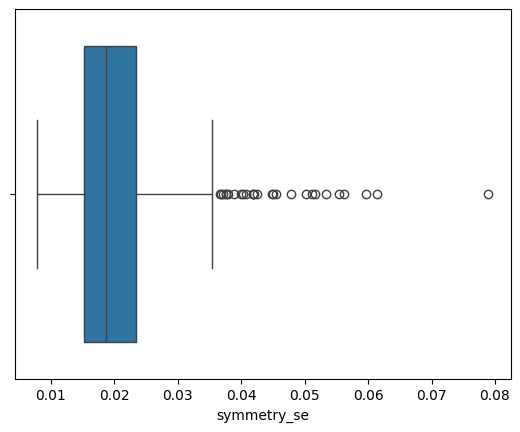

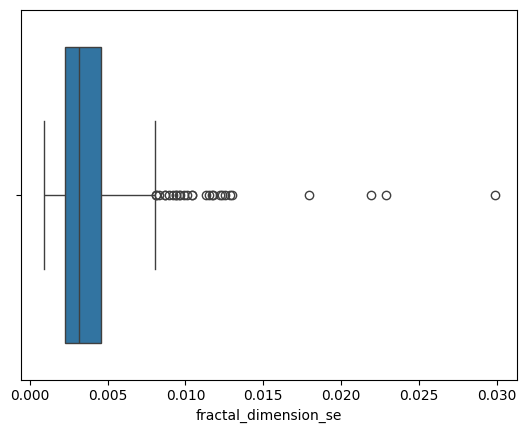

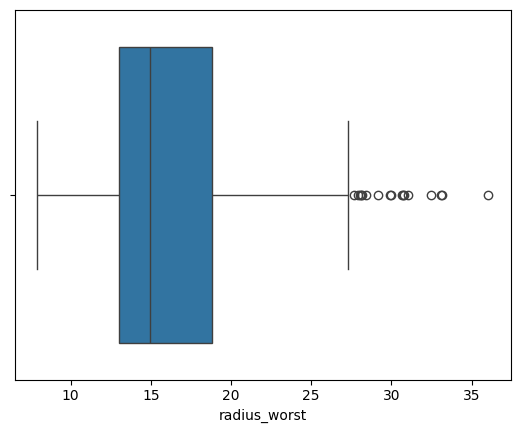

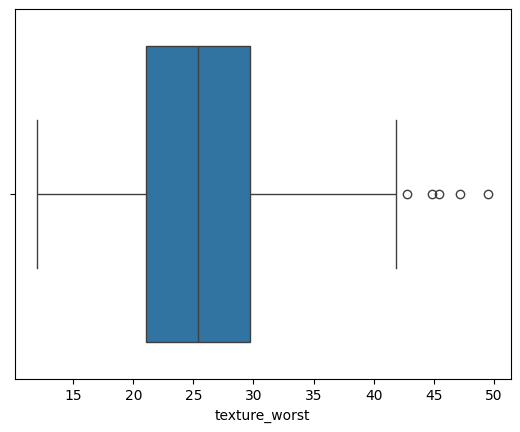

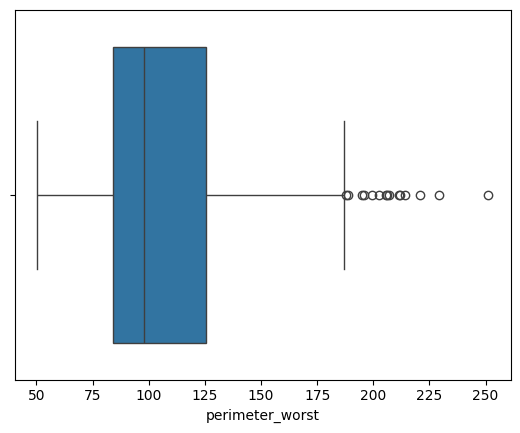

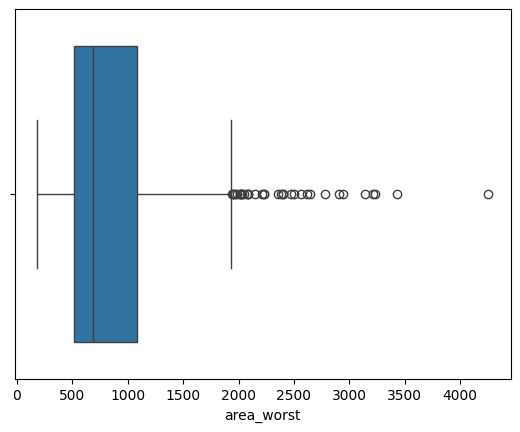

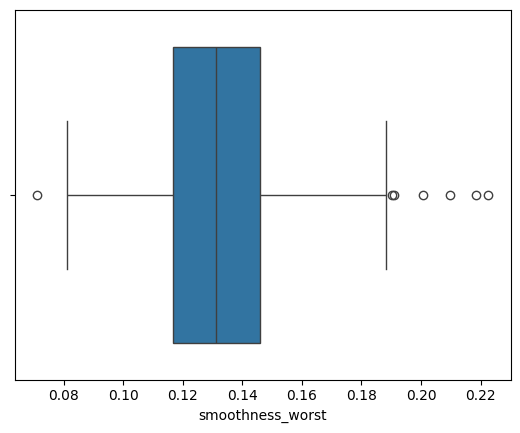

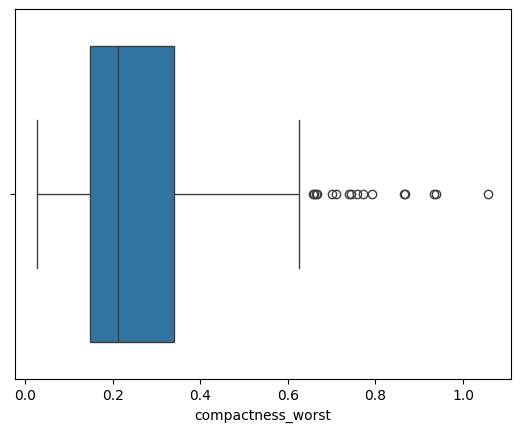

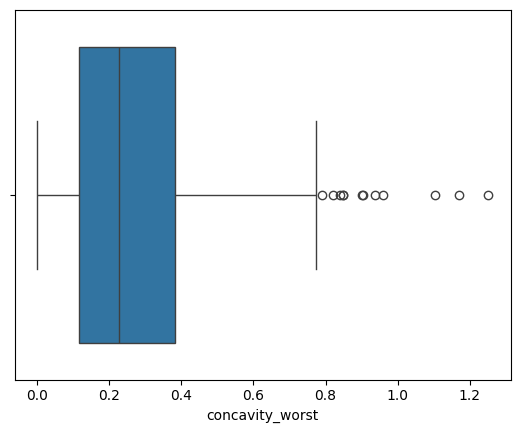

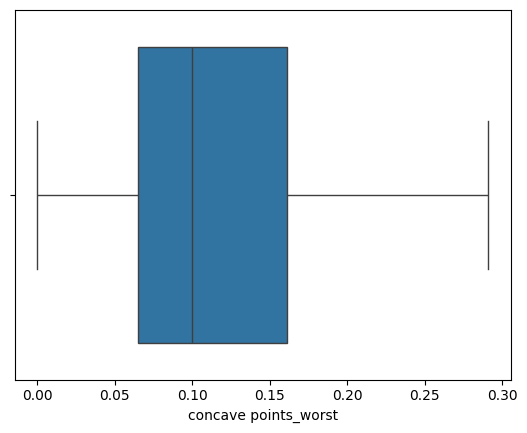

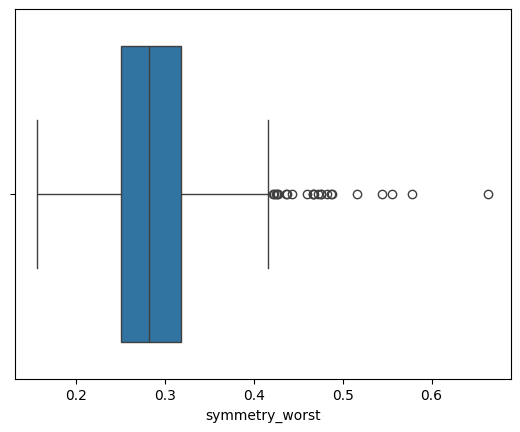

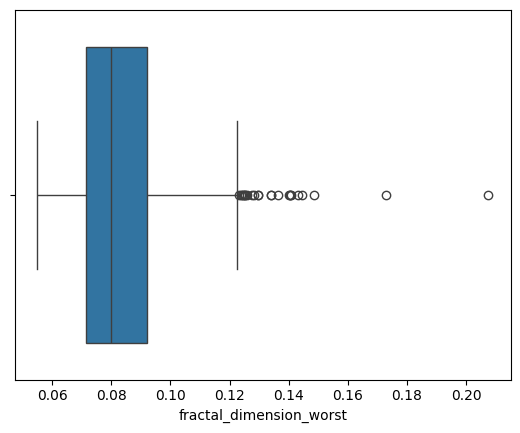

In [ ]:
for i in df.columns:
  sns.boxplot(x = df[i])
  plt.show()

<Axes: ylabel='radius_mean'>

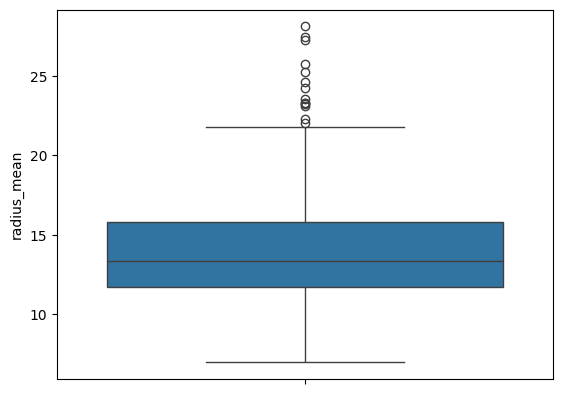

In [ ]:
sns.boxplot(df['radius_mean'])

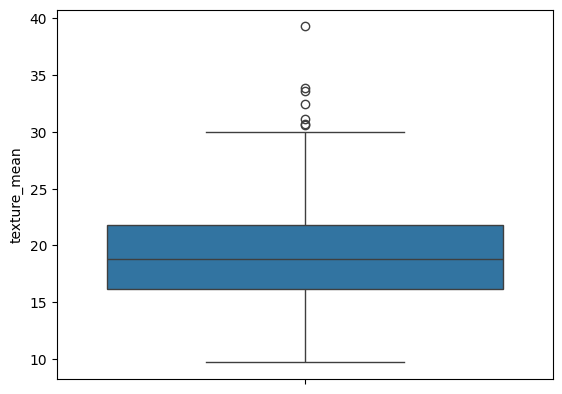

In [ ]:
sns.boxplot(df['texture_mean'])
df['texture_mean'] = winsorize(df['texture_mean'],(0,0.05))

In [ ]:
df.loc[df['radius_mean'] > 20.5 , 'radius_mean'] = np.mean(df['radius_mean'])

In [ ]:
from scipy.stats.mstats import winsorize
df['radius_mean'] = winsorize(df['radius_mean'],(0,0.05))

<Axes: ylabel='perimeter_mean'>

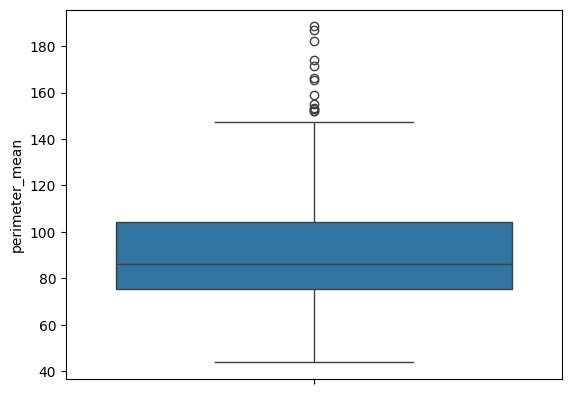

In [ ]:
sns.boxplot(df['perimeter_mean'])

In [ ]:
df.loc[df['perimeter_mean']>140,'perimeter_mean'] = np.mean(df['perimeter_mean'])

<Axes: ylabel='area_mean'>

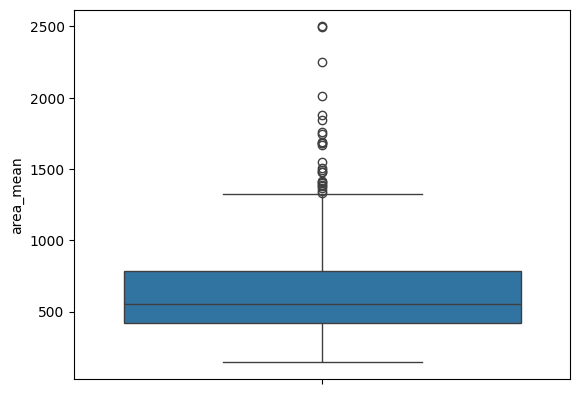

In [ ]:
sns.boxplot(df['area_mean'])

In [ ]:
df['area_mean'] = winsorize(df['area_mean'],(0,0.05))

<Axes: ylabel='smoothness_mean'>

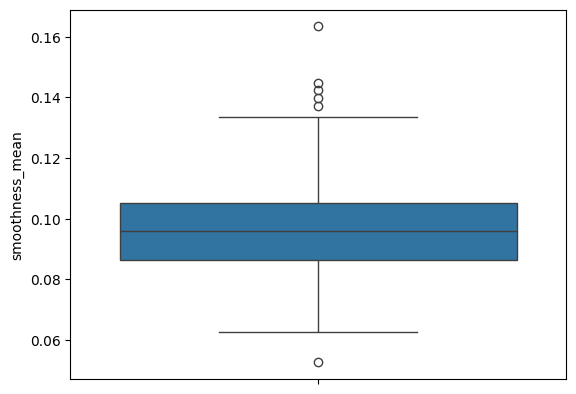

In [ ]:
sns.boxplot(df['smoothness_mean'])


In [ ]:
df['smoothness_mean'] = df.loc[(df['smoothness_mean']>0.06) & (df['smoothness_mean']<0.132),'smoothness_mean']

<Axes: ylabel='compactness_mean'>

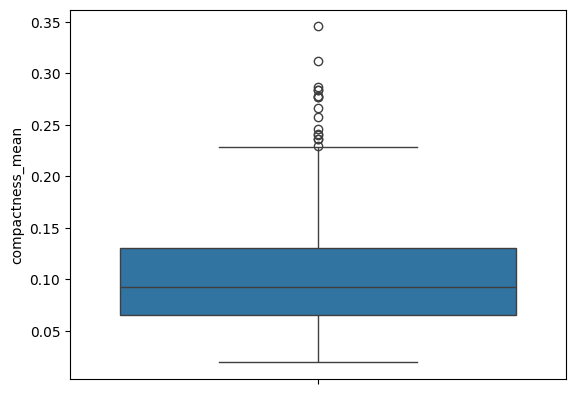

In [ ]:
sns.boxplot(df['compactness_mean'])
#df.loc[df['compactness_mean'] > 0.225,'compactness_mean'] = np.mean(df['compactness_mean'])

<Axes: ylabel='concavity_mean'>

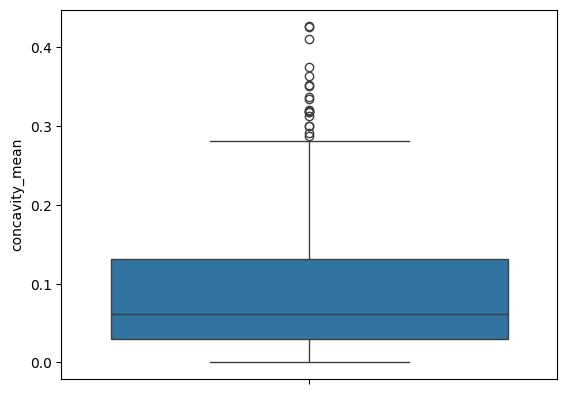

In [ ]:
sns.boxplot(df['concavity_mean'])

In [ ]:
df.loc[df['concavity_mean']>0.29,'concavity_mean'] = np.mean(df['concavity_mean'])
df['concavity_mean'] = winsorize(df['concavity_mean'],(0,0.05))

<Axes: ylabel='concave points_mean'>

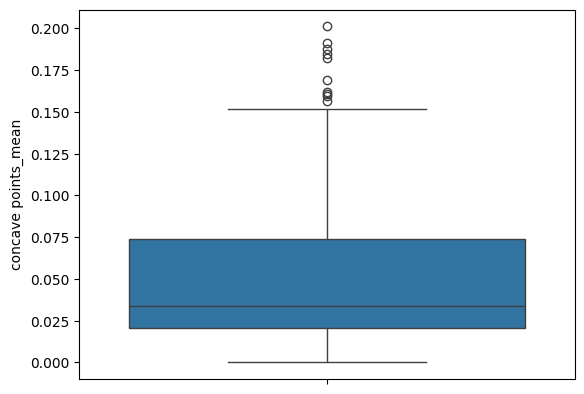

In [ ]:
sns.boxplot(df['concave points_mean'])

In [ ]:
df.loc[df['concave points_mean']>0.150,'concave points_mean'] = np.mean(df['concave points_mean'])
df['concave points_mean'] = winsorize(df['concave points_mean'],(0,0.05))

<Axes: ylabel='symmetry_mean'>

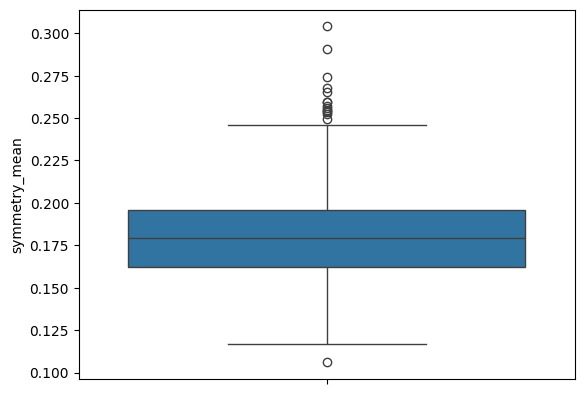

In [ ]:
sns.boxplot(df['symmetry_mean'])

In [ ]:
df['symmetry_mean'] = winsorize(df['symmetry_mean'],(0,0.05))
df['symmetry_mean'] = df.loc[df['symmetry_mean']>0.11,'symmetry_mean']

<Axes: ylabel='fractal_dimension_mean'>

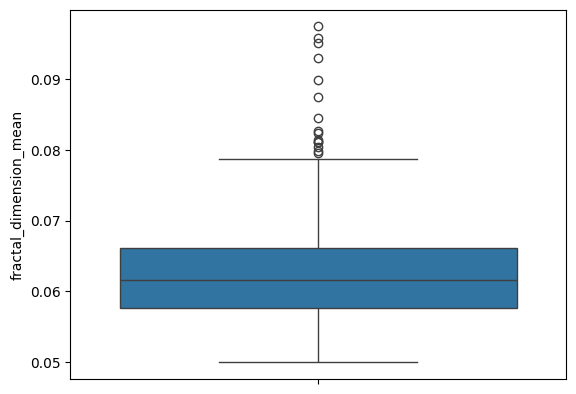

In [ ]:
sns.boxplot(df['fractal_dimension_mean'])

In [ ]:
df['fractal_dimension_mean'] = winsorize(df['fractal_dimension_mean'],(0,0.05))

In [ ]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')

In [ ]:
# prompt: list out the columns to be dropped in the list named columns_to_drop and then use drop command and drop them

columns_to_drop = ['perimeter_se', 'area_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se',
                  'smoothness_se', 'texture_se', 'radius_se', 'compactness_se',
                  'perimeter_worst', 'area_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst',
                  'fractal_dimension_worst', 'smoothness_worst', 'texture_worst', 'radius_worst', 'compactness_worst']

df.drop(columns=columns_to_drop, inplace=True)


In [ ]:
df1 = df

In [ ]:
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean
0,M,17.990000,10.38,122.80,1001.0,0.11840,0.27760,0.088799,0.11180,0.2310,0.07613
1,M,14.127292,17.77,132.90,1311.0,0.08474,0.07864,0.086900,0.07017,0.1812,0.05667
2,M,19.400000,21.25,130.00,1203.0,0.10960,0.15990,0.197400,0.11180,0.2069,0.05999
3,M,11.420000,20.38,77.58,386.1,NaN,0.28390,0.213600,0.10520,0.2310,0.07613
4,M,19.400000,14.34,135.10,1297.0,0.10030,0.13280,0.198000,0.10430,0.1809,0.05883


<Axes: >

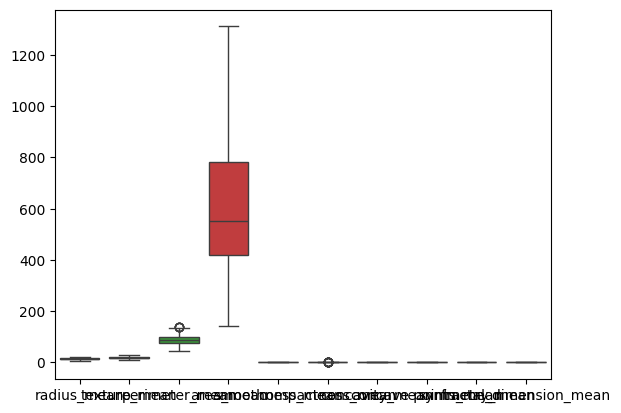

In [ ]:
sns.boxplot(df)

In [ ]:
df1.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean'],
      dtype='object')

<Axes: xlabel='area_mean', ylabel='radius_mean'>

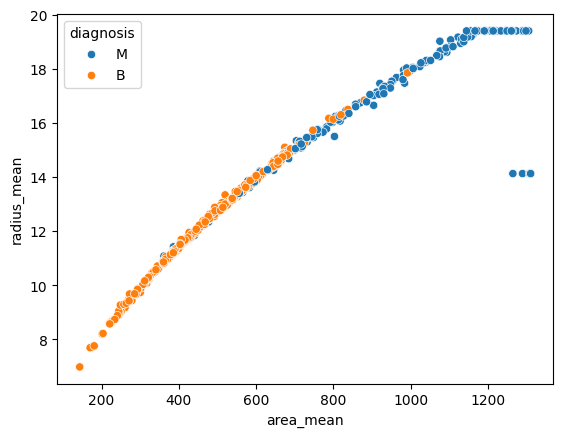

In [ ]:
sns.scatterplot(x = df['area_mean'], y = df['radius_mean'], hue = df['diagnosis'])

<ipython-input-100-27762f568c96>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df['diagnosis'],palette = 'plasma')


<Axes: xlabel='count', ylabel='diagnosis'>

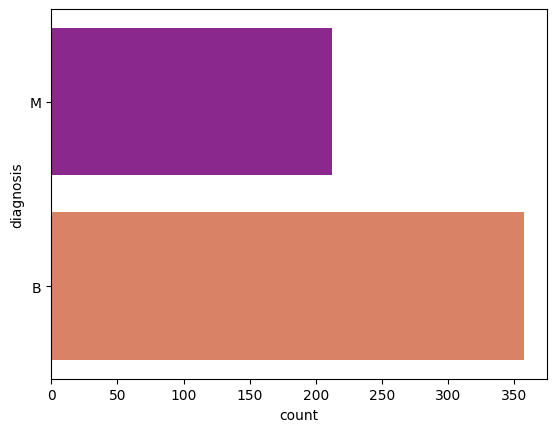

In [ ]:
sns.countplot(df['diagnosis'],palette = 'plasma')

<Axes: xlabel='diagnosis', ylabel='area_mean'>

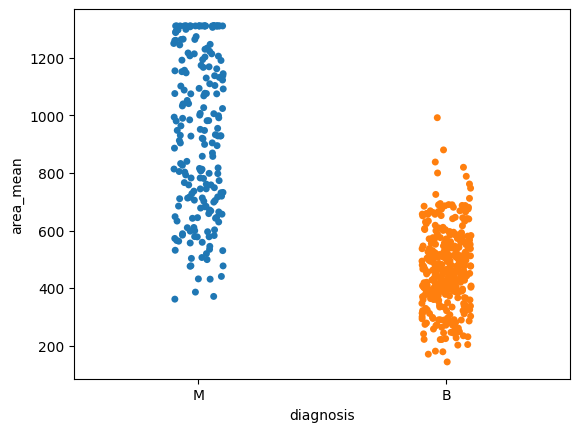

In [ ]:
sns.stripplot(x = df['diagnosis'], y = df['area_mean'],hue = df['diagnosis'])

<Axes: xlabel='symmetry_mean', ylabel='smoothness_mean'>

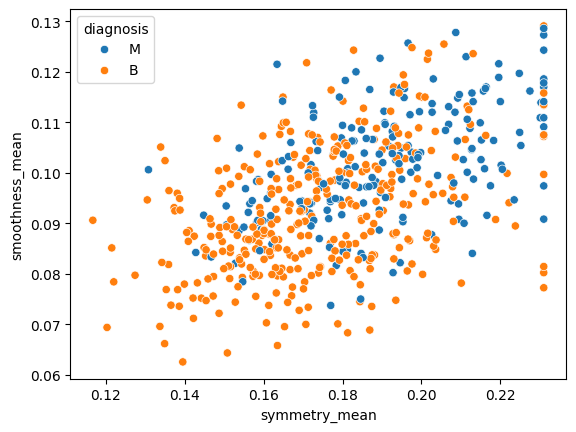

In [ ]:
sns.scatterplot(x = df['symmetry_mean'],y = df['smoothness_mean'],hue = df['diagnosis'])

<ipython-input-103-853df669ec12>:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['symmetry_mean'],palette = 'plasma')


<Axes: xlabel='symmetry_mean', ylabel='Count'>

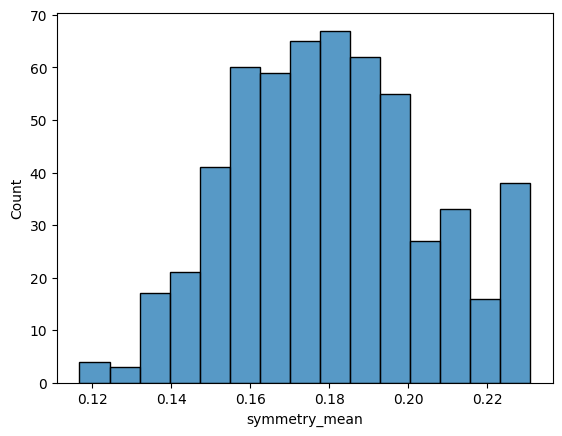

In [ ]:
sns.histplot(df['symmetry_mean'],palette = 'plasma')

In [ ]:
df.columns

Index(['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   diagnosis               569 non-null    object 
 1   radius_mean             569 non-null    float64
 2   texture_mean            569 non-null    float64
 3   perimeter_mean          569 non-null    float64
 4   area_mean               569 non-null    float64
 5   smoothness_mean         560 non-null    float64
 6   compactness_mean        569 non-null    float64
 7   concavity_mean          569 non-null    float64
 8   concave points_mean     569 non-null    float64
 9   symmetry_mean           568 non-null    float64
 10  fractal_dimension_mean  569 non-null    float64
dtypes: float64(10), object(1)
memory usage: 49.0+ KB


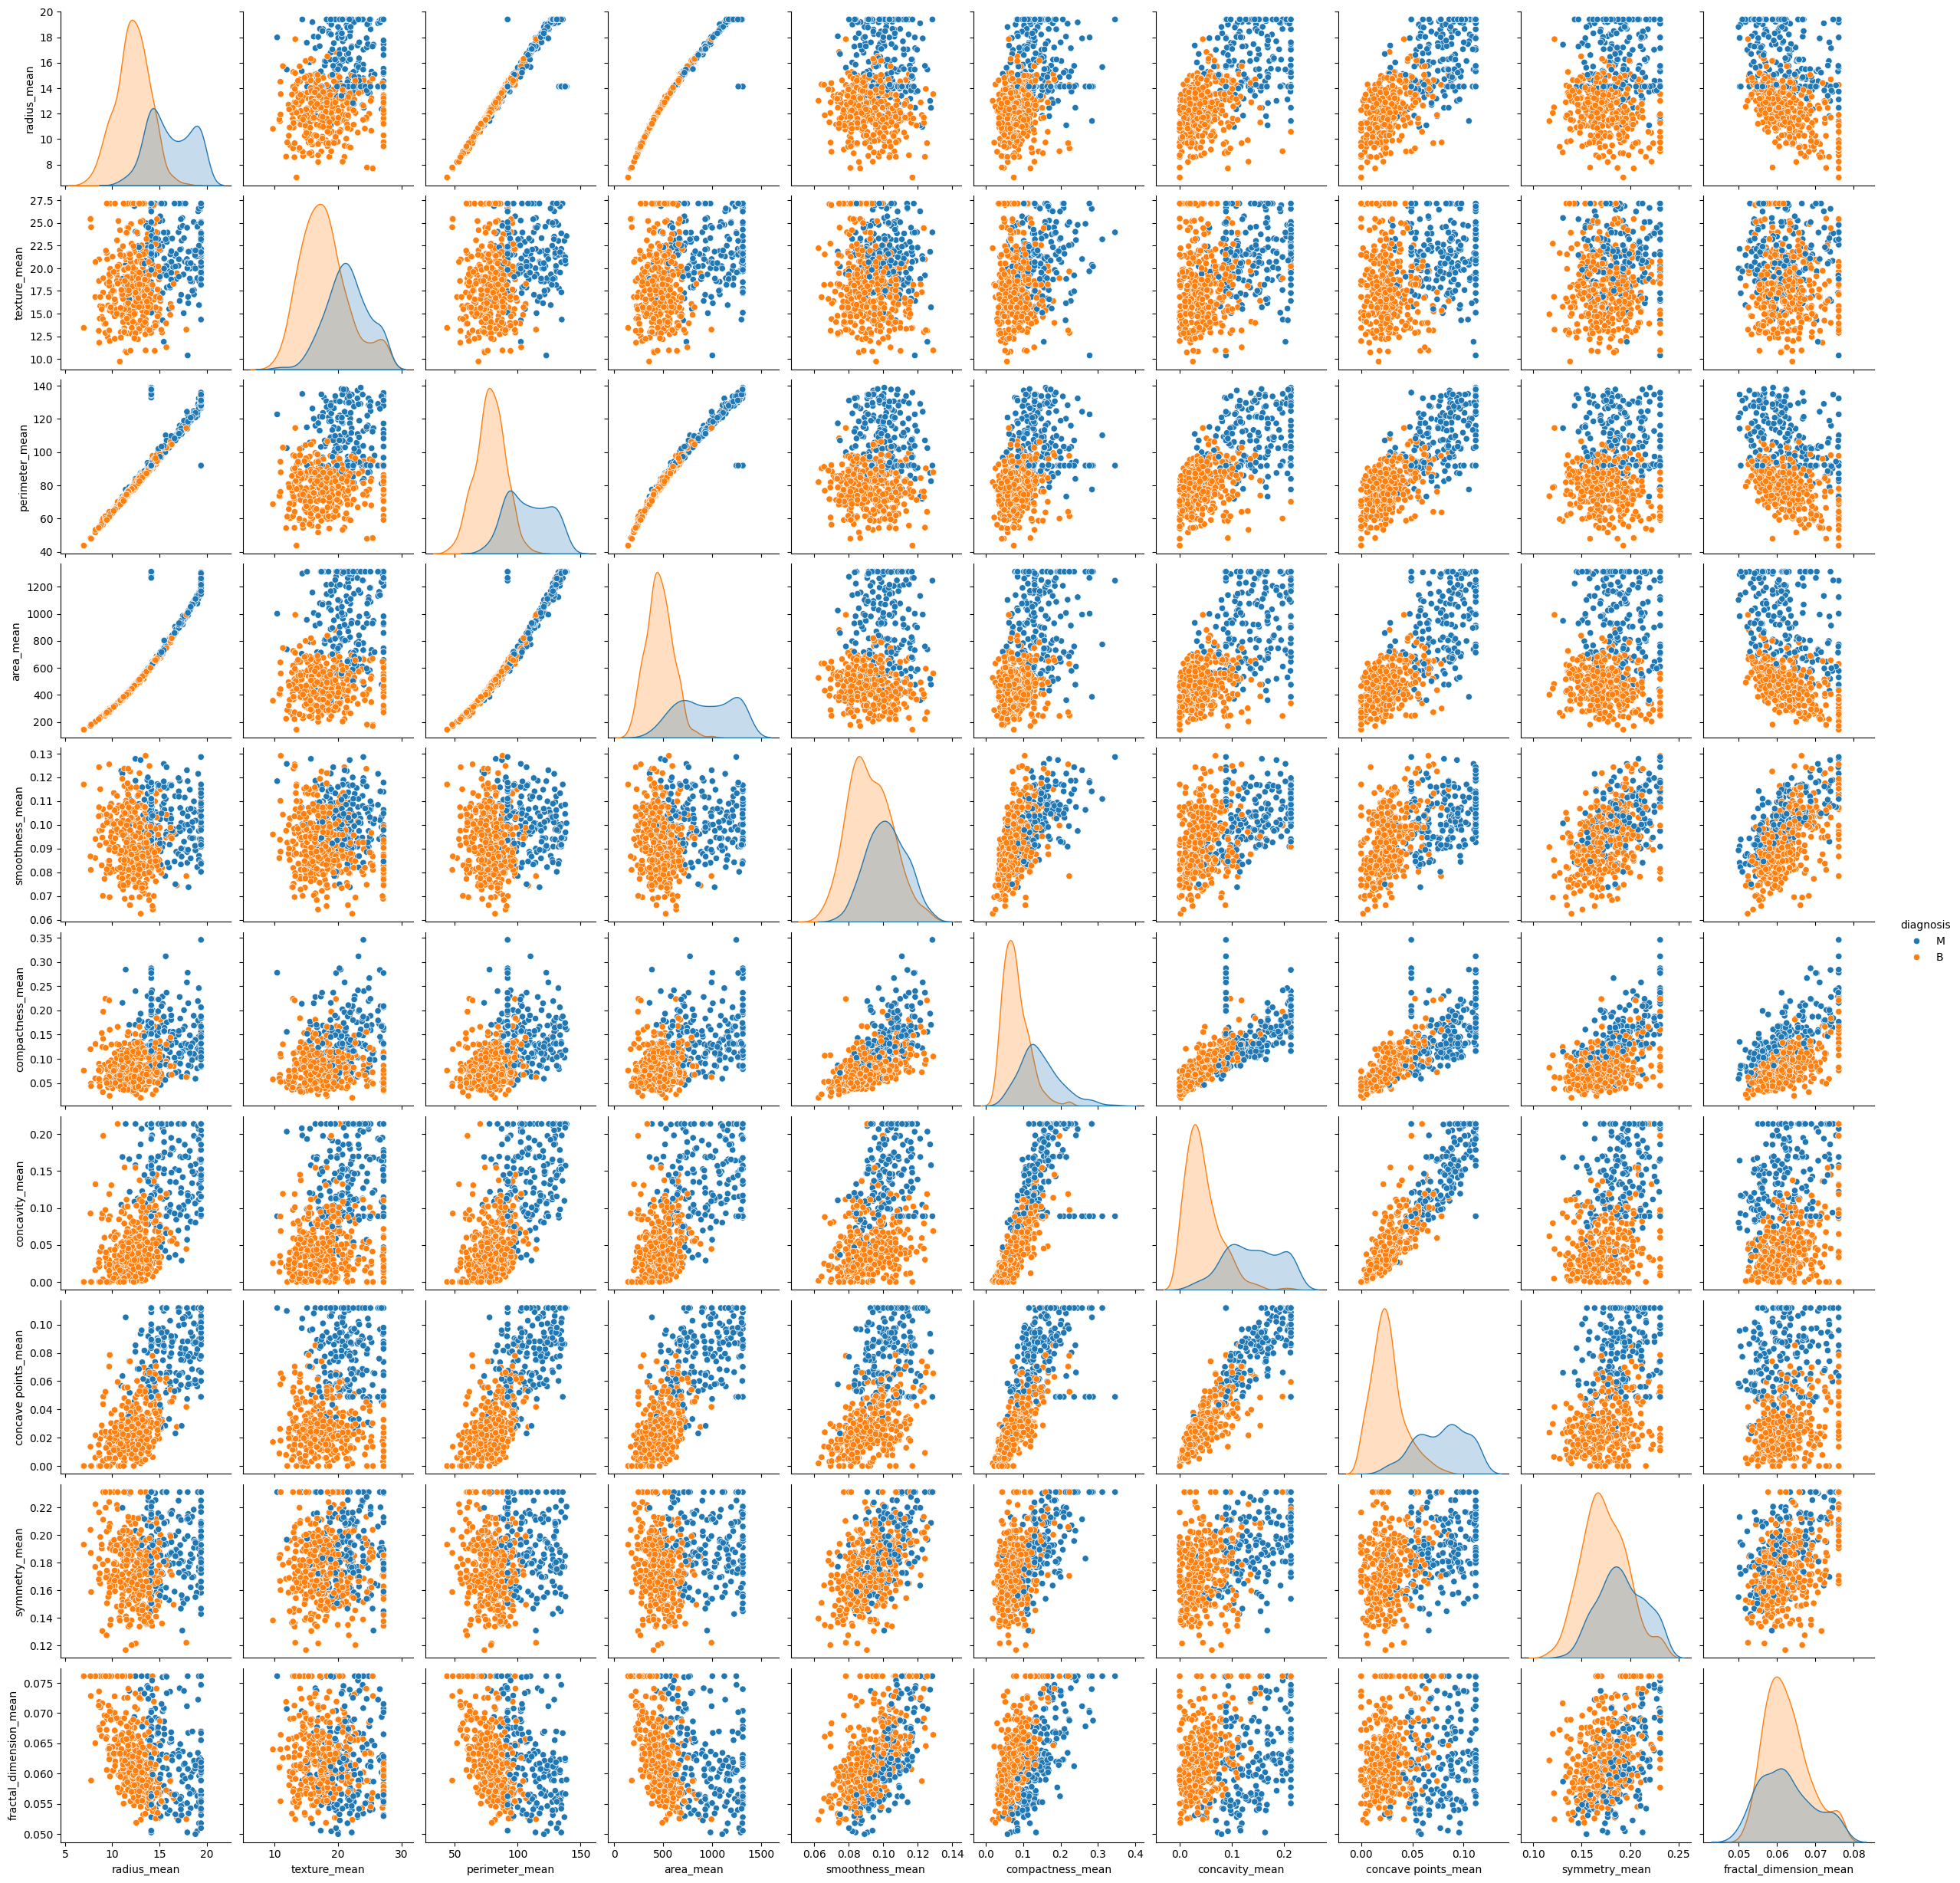

In [ ]:
sns.pairplot(df,hue = 'diagnosis')

In [ ]:
X = df.drop(['diagnosis'],axis=1)
y = df['diagnosis']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state =42)

In [ ]:
knn = KNeighborsClassifier()
rfc = RandomForestClassifier()
dtc = DecisionTreeClassifier()
gbc = GradientBoostingClassifier()
svc = SVC()
gnb = GaussianNB()

In [ ]:
knn.fit(X_train,y_train)
rfc.fit(X_train,y_train)
dtc.fit(X_train,y_train)
gbc.fit(X_train,y_train)
svc.fit(X_train,y_train)

SVC()

In [ ]:
df.isnull().sum()

,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0
symmetry_mean,0


<Axes: >

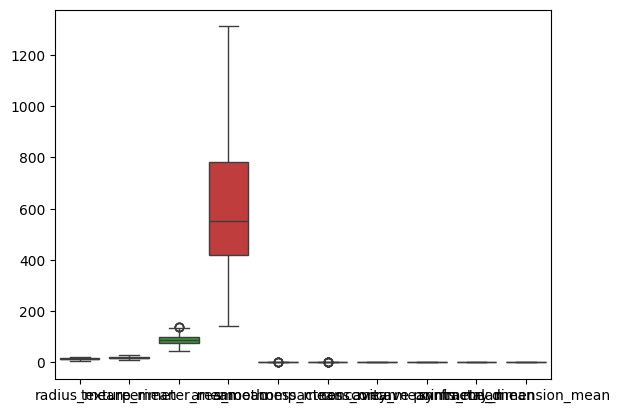

In [ ]:
sns.boxplot(df)

In [ ]:
np.mean(df['symmetry_mean'])

0.18029084507042256

In [ ]:
df.fillna(np.mean(df['symmetry_mean']),inplace=True)

In [ ]:
y_pred01 = knn.predict(X_test)
y_pred02 = rfc.predict(X_test)
y_pred03 = dtc.predict(X_test)
y_pred04 = gbc.predict(X_test)
y_pred05 = svc.predict(X_test)

In [ ]:
KNN = accuracy_score(y_test,y_pred01)
RFC = accuracy_score(y_test,y_pred02)
DTC = accuracy_score(y_test,y_pred03)
GBC = accuracy_score(y_test,y_pred04)
SVC = accuracy_score(y_test,y_pred05)

In [ ]:
kNN = precision_score(y_test,y_pred01,pos_label='M')
rFC = precision_score(y_test,y_pred02,pos_label='M')
dTC = precision_score(y_test,y_pred03,pos_label='M')
gBC = precision_score(y_test,y_pred04,pos_label='M')
sVC = precision_score(y_test,y_pred05,pos_label='M')

In [ ]:
KNc = recall_score(y_test,y_pred01,pos_label='M')
RFc = recall_score(y_test,y_pred02,pos_label='M')
DTc = recall_score(y_test,y_pred03,pos_label='M')
GBc = recall_score(y_test,y_pred04,pos_label='M')
SVc = recall_score(y_test,y_pred05,pos_label='M')

In [ ]:
l1 = sorted(lis1)

In [ ]:
lis1 = [KNN,RFC,DTC,GBC,SVC]
lis2 = [kNN,rFC,dTC,gBC,sVC]
lis3 = [KNc,RFc,DTc,GBc,SVc]

In [ ]:
l1 = sorted(lis1)

In [ ]:
l2 = sorted(lis2)

In [ ]:
l3 = sorted(lis3)

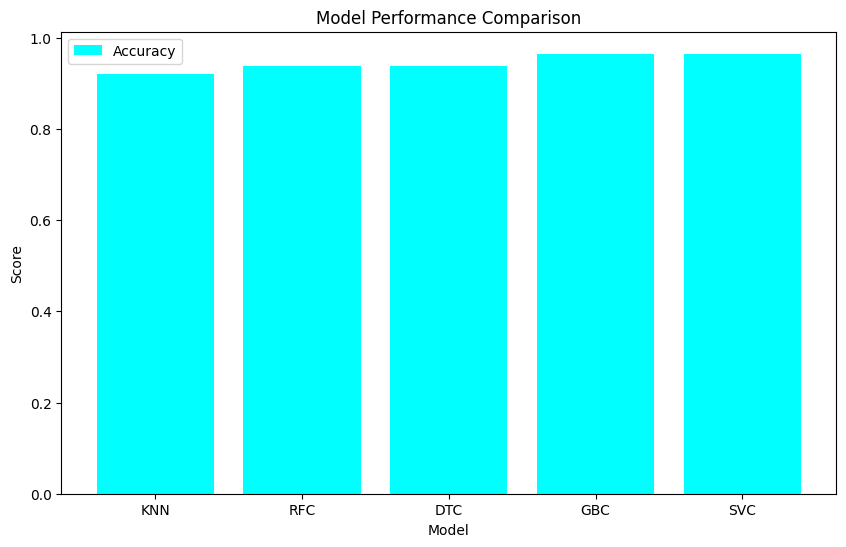

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(['KNN', 'RFC', 'DTC', 'GBC', 'SVC'], l1, label='Accuracy',color = 'cyan')
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()
#plt.bar(['KNN', 'RFC', 'DTC', 'GBC', 'SVC'], lis3, label='Recall')

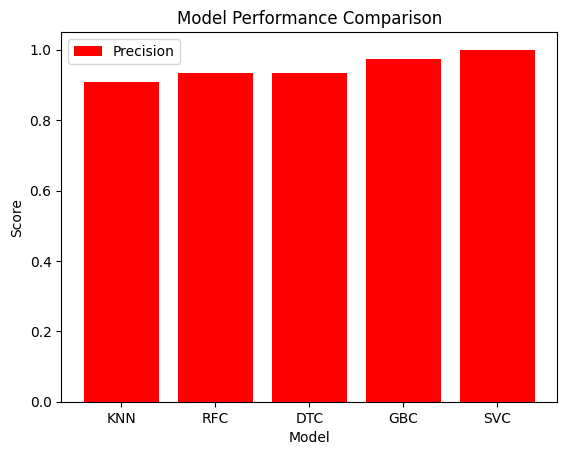

In [ ]:
plt.bar(['KNN', 'RFC', 'DTC', 'GBC', 'SVC'], l2, label='Precision',color = 'red')
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

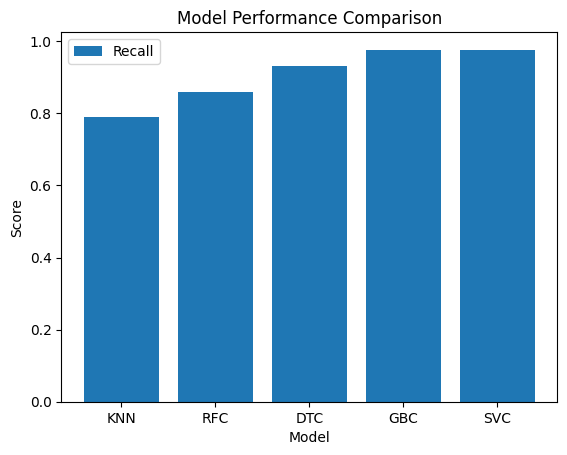

In [ ]:
plt.bar(['KNN', 'RFC', 'DTC', 'GBC', 'SVC'], l3, label='Recall')
plt.xlabel('Model')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.legend()
plt.show()

In [ ]:
type(l1)

list

In [ ]:
l1_col = ['KNN','RFC','DTC','GBC','SVC']
Df1 = pd.DataFrame(l1_col,columns = ['Accuracy'])

In [ ]:
Df1 = pd.DataFrame({'Model': l1_col, 'Accuracy': l1})
Df2 = pd.DataFrame({'Model': l1_col, 'Precision': l2})
Df3 = pd.DataFrame({'Model': l1_col, 'Recall': l3})

In [ ]:
Df1

,Model,Accuracy
0,KNN,0.921053
1,RFC,0.938596
2,DTC,0.938596
3,GBC,0.964912
4,SVC,0.964912


In [ ]:
Df2

,Model,Precision
0,KNN,0.909091
1,RFC,0.933333
2,DTC,0.933333
3,GBC,0.973684
4,SVC,1.000000


In [ ]:
Df3

,Model,Recall
0,KNN,0.790698
1,RFC,0.860465
2,DTC,0.930233
3,GBC,0.976744
4,SVC,0.976744


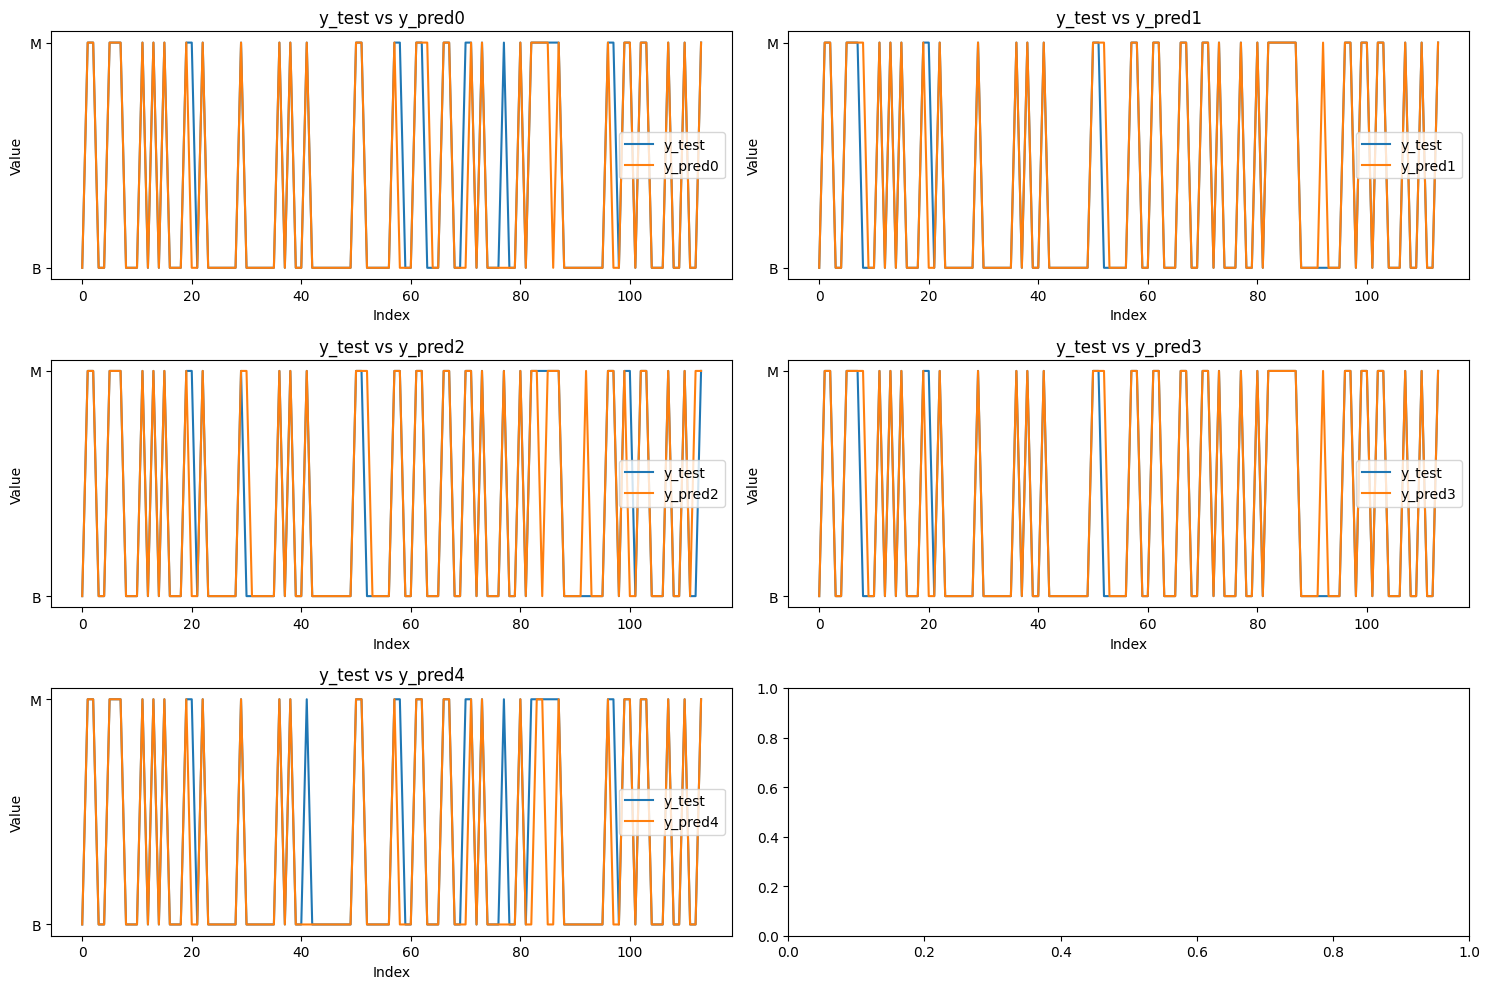

In [ ]:
#AI Generated Plot for advanced analysis of data.
plt.figure(figsize=(15, 10))
for i in range(6):
    plt.subplot(3, 2, i + 1)
    if i == 0:
        plt.plot(y_test.values, label='y_test')
        plt.plot(y_pred01, label='y_pred0')
    elif i ==1:
        plt.plot(y_test.values, label='y_test')
        plt.plot(y_pred02, label='y_pred1')
    elif i == 2:
        plt.plot(y_test.values, label='y_test')
        plt.plot(y_pred03, label='y_pred2')
    elif i == 3:
        plt.plot(y_test.values, label='y_test')
        plt.plot(y_pred04, label='y_pred3')
    elif i == 4:
        plt.plot(y_test.values, label='y_test')
        plt.plot(y_pred05, label='y_pred4')
    else:
      break
    plt.title(f'y_test vs y_pred{i}')
    plt.xlabel('Index')
    plt.ylabel('Value')
    plt.legend()
plt.tight_layout()
plt.show()
